# 05 - Preguntas Analíticas - Catastro DNC

En este notebook se responden preguntas analíticas sobre el modelo de Catastro construido en las etapas anteriores.

Las consultas se realizan sobre las tablas Hive de la base `obligatorio_catastro`, creadas a partir del modelo curated ubicado en `/cur/obligatorio_catastro`.

Los resultados principales se guardan en la zona analítica del datalake:

`/anl/obligatorio_catastro`


## 1. Inicialización del entorno Spark con soporte Hive

Se inicializa una sesión Spark con soporte Hive para consultar las tablas externas creadas en el notebook anterior.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Obligatorio Catastro - Preguntas Analiticas") \
    .enableHiveSupport() \
    .getOrCreate()

spark


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-06-22T23:50:13,585 WARN [Thread-4] org.apache.hadoop.util.NativeCodeLoader - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Definición de base Hive y ruta analítica

Se define la base Hive que contiene el modelo analítico y la ruta HDFS donde se almacenarán los resultados de las preguntas.


In [2]:
HIVE_DB = "obligatorio_catastro"
ANL_PATH = "/anl/obligatorio_catastro"

spark.sql(f"USE {HIVE_DB}")

print("Base Hive:", HIVE_DB)
print("Ruta ANL:", ANL_PATH)


2026-06-22T23:50:22,212 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/home/ort/spark/conf/hive-site.xml
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.metastore.wm.default.pool.size does not exist
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.task.scheduler.preempt.independent does not exist
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.output.format.arrow does not exist
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.tez.llap.min.reducer.per.executor does not exist
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.arrow.root.allocator.limit does not exist
2026-06-22T23:50:22,465 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.vectorized.use.che

## 3. Validación inicial de tablas disponibles

Antes de responder las preguntas analíticas, se valida que las tablas Hive del modelo estén disponibles.


In [3]:
spark.sql("SHOW TABLES").show(50, truncate=False)


[Stage 0:>                                                          (0 + 1) / 1]

+--------------------+--------------------------+-----------+
|namespace           |tableName                 |isTemporary|
+--------------------+--------------------------+-----------+
|obligatorio_catastro|dim_categoria_construccion|false      |
|obligatorio_catastro|dim_cielorraso            |false      |
|obligatorio_catastro|dim_cubierta              |false      |
|obligatorio_catastro|dim_departamento          |false      |
|obligatorio_catastro|dim_destino               |false      |
|obligatorio_catastro|dim_estado_conservacion   |false      |
|obligatorio_catastro|dim_localidad             |false      |
|obligatorio_catastro|dim_tipo_obra             |false      |
|obligatorio_catastro|fact_historico_valores    |false      |
|obligatorio_catastro|fact_lineas_construccion  |false      |
|obligatorio_catastro|fact_padrones_rurales     |false      |
|obligatorio_catastro|fact_padrones_urbanos     |false      |
+--------------------+--------------------------+-----------+



## 4. Preguntas analíticas

A partir del modelo Hive de Catastro, se definen las siguientes preguntas analíticas:

1. ¿Qué departamentos concentran mayor valor catastral urbano?
2. ¿Cómo se distribuyen las construcciones por antigüedad?
3. ¿Qué destinos de construcción concentran mayor área construida?
4. ¿Cómo se distribuyen las líneas de construcción según estado de conservación?
5. ¿Qué departamentos presentan mayor variación en el valor catastral histórico?

Este conjunto de preguntas permite analizar el dominio desde perspectivas distintas: valor urbano, antigüedad del parque construido, uso o destino de las construcciones, estado de conservación y evolución histórica del valor catastral.


## 5. Pregunta 1: ¿Qué departamentos concentran mayor valor catastral urbano?

Esta pregunta analiza la distribución del valor catastral urbano por departamento.

Se utiliza la tabla de hechos `fact_padrones_urbanos`, que contiene los padrones urbanos y sus medidas catastrales, junto con la dimensión `dim_departamento`, que permite obtener el nombre del departamento.

Para cada departamento se calcula:

- Cantidad de padrones urbanos.
- Área total de predios urbanos.
- Área edificada total.
- Valor catastral urbano total.
- Valor catastral promedio por padrón urbano.

El objetivo es identificar qué departamentos concentran mayor valor catastral urbano dentro del conjunto de datos.


In [4]:
q1_valor_urbano_departamento = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_padrones_urbanos,
    SUM(p.area_predio) AS area_predio_total,
    SUM(p.area_edificada) AS area_edificada_total,
    SUM(p.valor_catastral_total) AS valor_catastral_total,
    ROUND(AVG(p.valor_catastral_total), 2) AS valor_catastral_promedio
FROM obligatorio_catastro.fact_padrones_urbanos p
JOIN obligatorio_catastro.dim_departamento d
    ON p.codigo_departamento = d.codigo_departamento
GROUP BY d.departamento
ORDER BY valor_catastral_total DESC
""")

q1_valor_urbano_departamento.show(20, truncate=False)


[Stage 3:>                                                          (0 + 2) / 2]

+--------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|departamento  |cantidad_padrones_urbanos|area_predio_total|area_edificada_total|valor_catastral_total|valor_catastral_promedio|
+--------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|MONTEVIDEO    |471929                   |1796925608       |56591607            |1200451164942        |2543711.37              |
|MALDONADO     |172651                   |1290455517       |22904821            |372452695003         |2157257.68              |
|CANELONES     |232253                   |524626988        |26887172            |258014601023         |1110920.42              |
|COLONIA       |67085                    |154552679        |5362305             |82437017561          |1228844.27              |
|SALTO         |44086                    |111736329        |4562537             |56291495931     

In [5]:
q1_output_path = f"{ANL_PATH}/q1_valor_urbano_departamento"

(
    q1_valor_urbano_departamento
    .write
    .mode("overwrite")
    .parquet(q1_output_path)
)

print("Resultado guardado en:", q1_output_path)


[Stage 14:>                                                         (0 + 1) / 1]

Resultado guardado en: /anl/obligatorio_catastro/q1_valor_urbano_departamento


### Resultado de la Pregunta 1

La consulta permite observar qué departamentos concentran mayor valor catastral urbano total.

Este análisis muestra la concentración territorial del valor urbano registrado por Catastro. Los departamentos con mayor cantidad de padrones urbanos, mayor área edificada y mayor actividad inmobiliaria tienden a concentrar los valores catastrales más altos.

La métrica de valor catastral promedio permite complementar el análisis, ya que un departamento puede tener menor cantidad de padrones, pero mayor valor promedio por padrón.


## 6. Pregunta 2: ¿Cómo se distribuyen las construcciones por antigüedad?

Esta pregunta analiza la antigüedad del parque construido registrado en la tabla `fact_lineas_construccion`.

A partir del campo `anio_construccion`, se agrupan las líneas de construcción en rangos temporales:

- Antes de 1950.
- 1950 - 1979.
- 1980 - 1999.
- 2000 - 2019.
- 2020 en adelante.
- Sin año informado.

Para cada rango se calcula:

- Cantidad de líneas de construcción.
- Área construida total.
- Área construida promedio.
- Año mínimo.
- Año máximo.

El objetivo es identificar qué períodos concentran mayor cantidad de construcciones y mayor superficie construida.


In [6]:
q2_antiguedad_construcciones = spark.sql("""
SELECT
    CASE
        WHEN anio_construccion IS NULL THEN 'Sin año informado'
        WHEN anio_construccion < 1950 THEN 'Antes de 1950'
        WHEN anio_construccion BETWEEN 1950 AND 1979 THEN '1950 - 1979'
        WHEN anio_construccion BETWEEN 1980 AND 1999 THEN '1980 - 1999'
        WHEN anio_construccion BETWEEN 2000 AND 2019 THEN '2000 - 2019'
        WHEN anio_construccion >= 2020 THEN '2020 en adelante'
        ELSE 'Sin clasificar'
    END AS rango_antiguedad,
    COUNT(*) AS cantidad_lineas,
    SUM(area_construida) AS area_construida_total,
    ROUND(AVG(area_construida), 2) AS area_construida_promedio,
    MIN(anio_construccion) AS anio_minimo,
    MAX(anio_construccion) AS anio_maximo
FROM obligatorio_catastro.fact_lineas_construccion
GROUP BY
    CASE
        WHEN anio_construccion IS NULL THEN 'Sin año informado'
        WHEN anio_construccion < 1950 THEN 'Antes de 1950'
        WHEN anio_construccion BETWEEN 1950 AND 1979 THEN '1950 - 1979'
        WHEN anio_construccion BETWEEN 1980 AND 1999 THEN '1980 - 1999'
        WHEN anio_construccion BETWEEN 2000 AND 2019 THEN '2000 - 2019'
        WHEN anio_construccion >= 2020 THEN '2020 en adelante'
        ELSE 'Sin clasificar'
    END
ORDER BY
    CASE rango_antiguedad
        WHEN 'Antes de 1950' THEN 1
        WHEN '1950 - 1979' THEN 2
        WHEN '1980 - 1999' THEN 3
        WHEN '2000 - 2019' THEN 4
        WHEN '2020 en adelante' THEN 5
        WHEN 'Sin año informado' THEN 6
        ELSE 7
    END
""")

q2_antiguedad_construcciones.show(truncate=False)


[Stage 15:>                                                         (0 + 2) / 2]

+-----------------+---------------+---------------------+------------------------+-----------+-----------+
|rango_antiguedad |cantidad_lineas|area_construida_total|area_construida_promedio|anio_minimo|anio_maximo|
+-----------------+---------------+---------------------+------------------------+-----------+-----------+
|Antes de 1950    |623635         |26724115             |42.85                   |3          |1949       |
|1950 - 1979      |1200274        |48804720             |40.66                   |1950       |1979       |
|1980 - 1999      |1076267        |39397285             |36.61                   |1980       |1999       |
|2000 - 2019      |1089664        |39695942             |36.43                   |2000       |2019       |
|2020 en adelante |403932         |12328213             |30.52                   |2020       |2026       |
|Sin año informado|84293          |5357015              |63.55                   |null       |null       |
+-----------------+---------------+--

In [7]:
q2_output_path = f"{ANL_PATH}/q2_antiguedad_construcciones"

(
    q2_antiguedad_construcciones
    .write
    .mode("overwrite")
    .parquet(q2_output_path)
)

print("Resultado guardado en:", q2_output_path)


Resultado guardado en: /anl/obligatorio_catastro/q2_antiguedad_construcciones


### Resultado de la Pregunta 2

Esta consulta permite analizar la antigüedad del parque construido registrado en Catastro.

Se agruparon las líneas de construcción en rangos de año de construcción, separando también los casos sin año informado. Esta clasificación permite identificar qué períodos concentran mayor cantidad de construcciones y mayor superficie construida.

La pregunta aporta una perspectiva temporal que complementa el análisis territorial y constructivo del modelo.


## 7. Pregunta 3: ¿Qué destinos de construcción concentran mayor área construida?

Esta pregunta analiza la tabla `fact_lineas_construccion` para identificar qué destinos concentran mayor área construida.

Se utiliza la dimensión `dim_destino` para obtener la descripción del destino de la construcción.

Para cada destino se calcula:

- Cantidad de líneas de construcción.
- Área construida total.
- Área construida promedio por línea.

El objetivo es conocer cuáles son los usos constructivos más relevantes dentro de los registros catastrales.


In [8]:
q3_area_construida_destino = spark.sql("""
SELECT
    d.destino,
    COUNT(*) AS cantidad_lineas,
    SUM(l.area_construida) AS area_construida_total,
    ROUND(AVG(l.area_construida), 2) AS area_construida_promedio
FROM obligatorio_catastro.fact_lineas_construccion l
LEFT JOIN obligatorio_catastro.dim_destino d
    ON l.codigo_destino = d.codigo_destino
WHERE l.area_construida > 0
GROUP BY d.destino
ORDER BY area_construida_total DESC
""")

q3_area_construida_destino.show(30, truncate=False)


[Stage 27:=============================>                            (1 + 1) / 2]

+--------------------------+---------------+---------------------+------------------------+
|destino                   |cantidad_lineas|area_construida_total|area_construida_promedio|
+--------------------------+---------------+---------------------+------------------------+
|VIVIENDA                  |1628893        |94832678             |58.22                   |
|DEPOSITO                  |402110         |17722159             |44.07                   |
|COMERCIO                  |64127          |6820559              |106.36                  |
|CUBIERTA,TECHADO,COBERTIZO|288415         |6264508              |21.72                   |
|MUROS                     |227677         |6027938              |26.48                   |
|GARAGE                    |93907          |5756371              |61.3                    |
|INDUSTRIA                 |8684           |3943239              |454.08                  |
|SALON                     |31451          |3194866              |101.58        

In [9]:
q3_output_path = f"{ANL_PATH}/q3_area_construida_destino"

(
    q3_area_construida_destino
    .write
    .mode("overwrite")
    .parquet(q3_output_path)
)

print("Resultado guardado en:", q3_output_path)


Resultado guardado en: /anl/obligatorio_catastro/q3_area_construida_destino


### Resultado de la Pregunta 3

Esta consulta permite identificar qué tipos de destino concentran la mayor superficie construida registrada.

Se espera que destinos asociados a vivienda, comercio, depósitos, garajes y otros usos frecuentes aparezcan entre los primeros lugares.

El análisis permite observar no solo los destinos más frecuentes, sino también aquellos con mayor área promedio por línea de construcción.


## 8. Pregunta 4: ¿Cómo se distribuyen las líneas de construcción según estado de conservación?

Esta pregunta analiza cómo se distribuyen las líneas de construcción según su estado de conservación.

Se utiliza la tabla `fact_lineas_construccion` junto con la dimensión `dim_estado_conservacion`.

Para cada estado se calcula:

- Cantidad de líneas de construcción.
- Área construida total.
- Área construida promedio.
- Porcentaje de participación sobre el total de líneas.

El objetivo es conocer el estado general de conservación de las construcciones registradas.


In [10]:
q4_estado_conservacion = spark.sql("""
WITH base AS (
    SELECT
        COALESCE(e.estado_conservacion, 'Sin clasificar') AS estado_conservacion,
        COUNT(*) AS cantidad_lineas,
        SUM(l.area_construida) AS area_construida_total,
        ROUND(AVG(l.area_construida), 2) AS area_construida_promedio
    FROM obligatorio_catastro.fact_lineas_construccion l
    LEFT JOIN obligatorio_catastro.dim_estado_conservacion e
        ON l.codigo_estado = e.codigo_estado
    GROUP BY COALESCE(e.estado_conservacion, 'Sin clasificar')
),
total AS (
    SELECT SUM(cantidad_lineas) AS total_lineas
    FROM base
)
SELECT
    b.estado_conservacion,
    b.cantidad_lineas,
    b.area_construida_total,
    b.area_construida_promedio,
    ROUND((b.cantidad_lineas / t.total_lineas) * 100, 2) AS porcentaje_lineas
FROM base b
CROSS JOIN total t
ORDER BY b.cantidad_lineas DESC
""")

q4_estado_conservacion.show(20, truncate=False)


[Stage 41:=============================>                            (1 + 1) / 2]

+-------------------+---------------+---------------------+------------------------+-----------------+
|estado_conservacion|cantidad_lineas|area_construida_total|area_construida_promedio|porcentaje_lineas|
+-------------------+---------------+---------------------+------------------------+-----------------+
|Regular            |1787877        |69464593             |38.85                   |39.93            |
|Excelente          |818416         |23248282             |28.41                   |18.28            |
|Bueno              |688850         |30213916             |43.86                   |15.38            |
|Malo               |349287         |14154963             |40.53                   |7.8              |
|Bueno/Regular      |279202         |11429097             |40.93                   |6.23             |
|Regular/Malo       |271637         |10442280             |38.44                   |6.07             |
|Sin clasificar     |111074         |6550121              |58.97         

In [11]:
q4_output_path = f"{ANL_PATH}/q4_estado_conservacion"

(
    q4_estado_conservacion
    .write
    .mode("overwrite")
    .parquet(q4_output_path)
)

print("Resultado guardado en:", q4_output_path)


Resultado guardado en: /anl/obligatorio_catastro/q4_estado_conservacion


### Resultado de la Pregunta 4

Esta consulta permite conocer la distribución de las construcciones según su estado de conservación.

Se espera que los estados intermedios, como `Regular`, concentren una parte importante de las líneas. Los estados extremos, como `Excelente` o `Muy Malo`, permiten identificar segmentos particulares del parque construido.

El grupo `Sin clasificar` permite observar registros cuyos códigos no pudieron relacionarse con la dimensión de estados de conservación.


## 9. Pregunta 5: ¿Qué departamentos presentan mayor variación en el valor catastral histórico?

Esta pregunta utiliza la tabla `fact_historico_valores` para analizar la evolución del valor catastral por departamento.

Se compara el valor catastral total del año más reciente disponible contra el cuarto año registrado en la tabla histórica.

Para cada departamento se calcula:

- Cantidad de registros históricos.
- Valor catastral total del año 1.
- Valor catastral total del año 4.
- Variación absoluta.
- Variación porcentual.

El objetivo es identificar qué departamentos presentan mayor variación histórica del valor catastral.


In [12]:
q5_variacion_historica_valores = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_registros,
    SUM(h.valor_catastral_anio_1) AS valor_catastral_anio_1_total,
    SUM(h.valor_catastral_anio_4) AS valor_catastral_anio_4_total,
    SUM(h.valor_catastral_anio_1) - SUM(h.valor_catastral_anio_4) AS variacion_absoluta,
    ROUND(
        CASE
            WHEN SUM(h.valor_catastral_anio_4) = 0 THEN NULL
            ELSE ((SUM(h.valor_catastral_anio_1) - SUM(h.valor_catastral_anio_4)) / SUM(h.valor_catastral_anio_4)) * 100
        END,
        2
    ) AS variacion_porcentual
FROM obligatorio_catastro.fact_historico_valores h
JOIN obligatorio_catastro.dim_departamento d
    ON h.codigo_departamento = d.codigo_departamento
WHERE h.valor_catastral_anio_1 IS NOT NULL
  AND h.valor_catastral_anio_4 IS NOT NULL
GROUP BY d.departamento
ORDER BY variacion_absoluta DESC
""")

q5_variacion_historica_valores.show(20, truncate=False)


[Stage 65:>                                                         (0 + 2) / 2]

+--------------+------------------+----------------------------+----------------------------+------------------+--------------------+
|departamento  |cantidad_registros|valor_catastral_anio_1_total|valor_catastral_anio_4_total|variacion_absoluta|variacion_porcentual|
+--------------+------------------+----------------------------+----------------------------+------------------+--------------------+
|MONTEVIDEO    |463909            |1136597606312               |910978414634                |225619191678      |24.77               |
|MALDONADO     |175045            |315648688272                |251443513493                |64205174779       |25.53               |
|CANELONES     |264873            |252540775486                |196439240288                |56101535198       |28.56               |
|COLONIA       |83197             |102074931296                |80957785170                 |21117146126       |26.08               |
|SALTO         |52045             |84044406958                

In [13]:
q5_output_path = f"{ANL_PATH}/q5_variacion_historica_valores"

(
    q5_variacion_historica_valores
    .write
    .mode("overwrite")
    .parquet(q5_output_path)
)

print("Resultado guardado en:", q5_output_path)


Resultado guardado en: /anl/obligatorio_catastro/q5_variacion_historica_valores


### Resultado de la Pregunta 5

Esta consulta analiza la variación histórica del valor catastral por departamento utilizando la tabla `fact_historico_valores`.

La métrica de variación absoluta permite identificar qué departamentos aumentaron más en términos totales, mientras que la variación porcentual permite comparar la intensidad relativa del cambio.

Esta pregunta incorpora la dimensión temporal del conjunto de datos y complementa las preguntas territoriales y constructivas anteriores.


## 10. Validación de resultados guardados en zona analítica

Se valida que los resultados de las preguntas analíticas fueron guardados correctamente en la zona `/anl/obligatorio_catastro`.


In [14]:
resultados_anl = [
    "q1_valor_urbano_departamento",
    "q2_antiguedad_construcciones",
    "q3_area_construida_destino",
    "q4_estado_conservacion",
    "q5_variacion_historica_valores"
]

for resultado in resultados_anl:
    path = f"{ANL_PATH}/{resultado}"
    df = spark.read.parquet(path)

    print("=" * 80)
    print(resultado)
    print("Path:", path)
    print("Registros:", df.count())
    df.show(5, truncate=False)


q1_valor_urbano_departamento
Path: /anl/obligatorio_catastro/q1_valor_urbano_departamento
Registros: 19
+------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|departamento|cantidad_padrones_urbanos|area_predio_total|area_edificada_total|valor_catastral_total|valor_catastral_promedio|
+------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|MONTEVIDEO  |471929                   |1796925608       |56591607            |1200451164942        |2543711.37              |
|MALDONADO   |172651                   |1290455517       |22904821            |372452695003         |2157257.68              |
|CANELONES   |232253                   |524626988        |26887172            |258014601023         |1110920.42              |
|COLONIA     |67085                    |154552679        |5362305             |82437017561          |1228844.27              |
|SALTO 

## 11. Creación de tablas Hive para Superset

De acuerdo con la letra del obligatorio, dos de las preguntas analíticas se conservan como archivos en HDFS dentro de la zona analítica y se exponen como tablas Hive para ser utilizadas desde Superset.

En este caso se seleccionan:

- Pregunta 3: ¿Qué destinos de construcción concentran mayor área construida?
- Pregunta 4: ¿Cómo se distribuyen las líneas de construcción según estado de conservación?

Estas preguntas se eligen para Superset porque sus resultados son adecuados para construir gráficos de barras o torta que ayuden a interpretar la distribución de áreas construidas y estados de conservación.

In [15]:
# Crear tablas Hive analíticas para Superset

spark.sql(f"USE {HIVE_DB}")

spark.sql(f"""
DROP TABLE IF EXISTS {HIVE_DB}.anl_q3_area_construida_destino
""")

spark.sql(f"""
CREATE TABLE {HIVE_DB}.anl_q3_area_construida_destino
USING PARQUET
LOCATION '{ANL_PATH}/q3_area_construida_destino'
""")

spark.sql(f"""
DROP TABLE IF EXISTS {HIVE_DB}.anl_q4_estado_conservacion
""")

spark.sql(f"""
CREATE TABLE {HIVE_DB}.anl_q4_estado_conservacion
USING PARQUET
LOCATION '{ANL_PATH}/q4_estado_conservacion'
""")

spark.sql(f"""
SHOW TABLES IN {HIVE_DB} LIKE 'anl_*'
""").show(truncate=False)

2026-06-22T23:50:58,262 INFO [Thread-4] org.apache.hadoop.hive.ql.security.authorization.plugin.sqlstd.SQLStdHiveAccessController - Created SQLStdHiveAccessController for session context : HiveAuthzSessionContext [sessionString=a59e6881-303c-48a5-83f2-967f8bf63ffa, clientType=HIVECLI]
2026-06-22T23:50:58,265 WARN [Thread-4] org.apache.hadoop.hive.ql.session.SessionState - METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
2026-06-22T23:50:58,265 INFO [Thread-4] hive.metastore - Mestastore configuration hive.metastore.filter.hook changed from org.apache.hadoop.hive.metastore.DefaultMetaStoreFilterHookImpl to org.apache.hadoop.hive.ql.security.authorization.plugin.AuthorizationMetaStoreFilterHook
2026-06-22T23:50:58,269 INFO [Thread-4] hive.metastore - Closed a connection to metastore, current connections: 0
2026-06-22T23:50:58,270 INFO [Thread-4] hive.metastore - Trying to connect to metastore with URI thrift://l

In [16]:
# Validación de tablas Hive analíticas para Superset

spark.sql(f"""
SELECT *
FROM {HIVE_DB}.anl_q3_area_construida_destino
ORDER BY area_construida_total DESC
""").show(10, truncate=False)

spark.sql(f"""
SELECT *
FROM {HIVE_DB}.anl_q4_estado_conservacion
ORDER BY cantidad_lineas DESC
""").show(10, truncate=False)

+--------------------------+---------------+---------------------+------------------------+
|destino                   |cantidad_lineas|area_construida_total|area_construida_promedio|
+--------------------------+---------------+---------------------+------------------------+
|VIVIENDA                  |1628893        |94832678             |58.22                   |
|DEPOSITO                  |402110         |17722159             |44.07                   |
|COMERCIO                  |64127          |6820559              |106.36                  |
|CUBIERTA,TECHADO,COBERTIZO|288415         |6264508              |21.72                   |
|MUROS                     |227677         |6027938              |26.48                   |
|GARAGE                    |93907          |5756371              |61.3                    |
|INDUSTRIA                 |8684           |3943239              |454.08                  |
|SALON                     |31451          |3194866              |101.58        

## 12. Visualizaciones en Jupyter Notebook

De acuerdo con la letra del obligatorio, tres de las preguntas analíticas se llevan a DataFrame de pandas para generar visualizaciones dentro del notebook.

En este caso se visualizan:

- Pregunta 1: ¿Qué departamentos concentran mayor valor catastral urbano?
- Pregunta 2: ¿Cómo se distribuyen las construcciones por antigüedad?
- Pregunta 5: ¿Qué departamentos presentan mayor variación en el valor catastral histórico?

Las preguntas 3 y 4 se dejan para visualización en Superset, a partir de las tablas Hive creadas sobre los resultados almacenados en `/anl`.

> Si el entorno no tiene instaladas las librerías necesarias, ejecutar una sola vez:
>
> `!pip install --user pandas matplotlib`
>
> Luego reiniciar el kernel y volver a ejecutar las celdas iniciales del notebook.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt


### Visualización 1: Valor catastral urbano total por departamento

Se visualiza el ranking de departamentos según valor catastral urbano total.


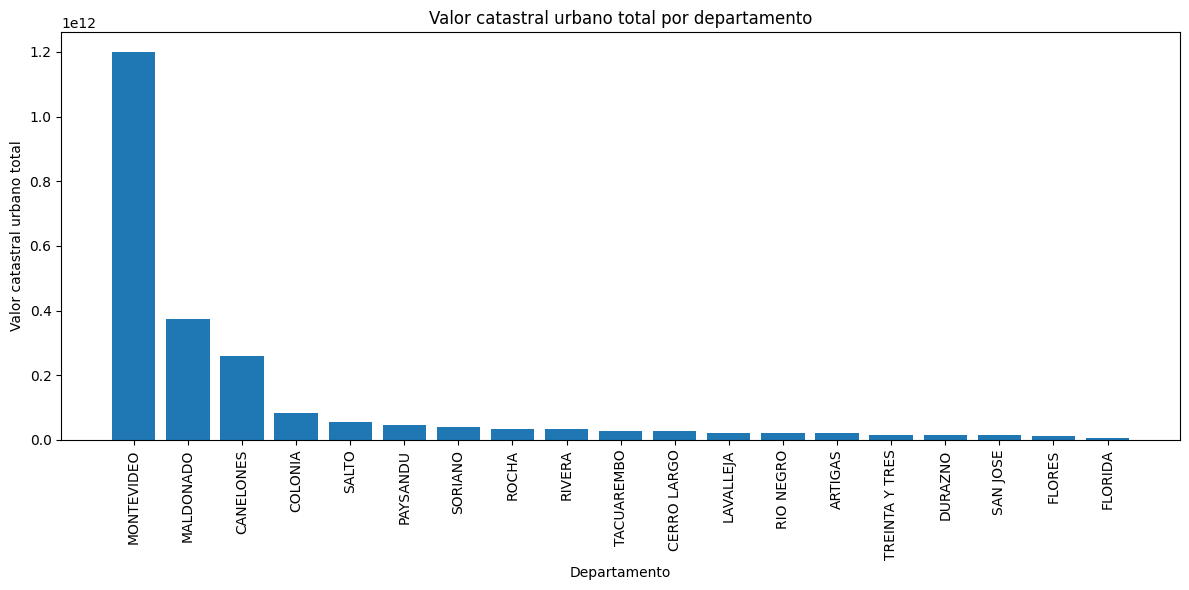

In [18]:
pdf_q1 = (
    spark.read
    .parquet(f"{ANL_PATH}/q1_valor_urbano_departamento")
    .orderBy(col("valor_catastral_total").desc())
    .toPandas()
)

plt.figure(figsize=(12, 6))
plt.bar(pdf_q1["departamento"], pdf_q1["valor_catastral_total"])
plt.xticks(rotation=90)
plt.xlabel("Departamento")
plt.ylabel("Valor catastral urbano total")
plt.title("Valor catastral urbano total por departamento")
plt.tight_layout()
plt.show()


### Visualización 2: Distribución de construcciones por antigüedad

Se visualiza la cantidad de líneas de construcción agrupadas por rango de antigüedad.


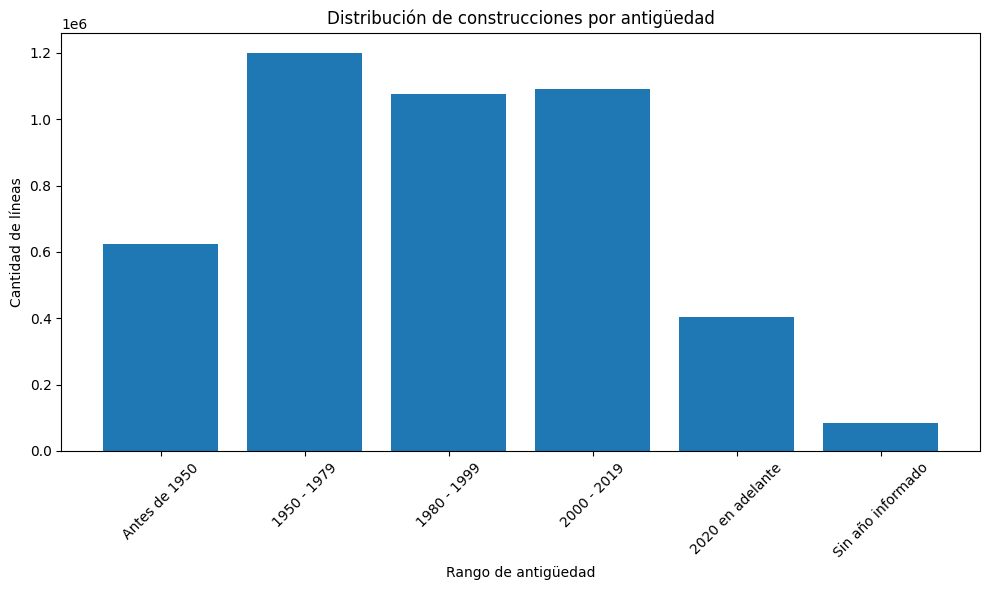

In [19]:
pdf_q2 = (
    spark.read
    .parquet(f"{ANL_PATH}/q2_antiguedad_construcciones")
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.bar(pdf_q2["rango_antiguedad"], pdf_q2["cantidad_lineas"])
plt.xticks(rotation=45)
plt.xlabel("Rango de antigüedad")
plt.ylabel("Cantidad de líneas")
plt.title("Distribución de construcciones por antigüedad")
plt.tight_layout()
plt.show()


### Visualización 3: Variación histórica del valor catastral por departamento

Se visualiza la variación absoluta del valor catastral entre los años históricos disponibles.


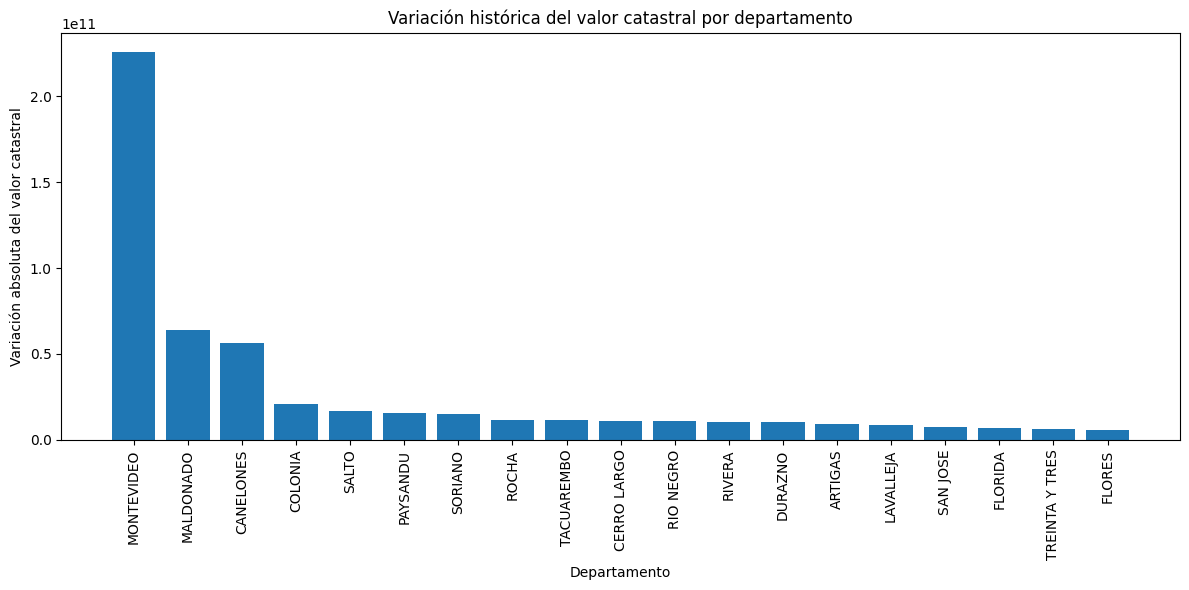

In [20]:
pdf_q5 = (
    spark.read
    .parquet(f"{ANL_PATH}/q5_variacion_historica_valores")
    .orderBy(col("variacion_absoluta").desc())
    .toPandas()
)

plt.figure(figsize=(12, 6))
plt.bar(pdf_q5["departamento"], pdf_q5["variacion_absoluta"])
plt.xticks(rotation=90)
plt.xlabel("Departamento")
plt.ylabel("Variación absoluta del valor catastral")
plt.title("Variación histórica del valor catastral por departamento")
plt.tight_layout()
plt.show()


## 13. Conclusiones del análisis

A partir de las consultas analíticas realizadas sobre las tablas Hive del modelo de Catastro, se concluye que:

- El valor catastral urbano se concentra principalmente en los departamentos con mayor desarrollo urbano e inmobiliario.
- La antigüedad de las construcciones permite observar la distribución temporal del parque construido registrado.
- El destino `VIVIENDA` concentra una parte relevante del área construida total.
- La distribución por estado de conservación permite evaluar la calidad general de las construcciones registradas.
- La tabla de histórico de valores permite analizar variaciones del valor catastral a nivel departamental.

Los resultados fueron guardados en la zona analítica `/anl/obligatorio_catastro`, completando el flujo del datalake desde la ingesta hasta la explotación analítica.
